In [ ]:
import ee
import cubo
import sys
import matplotlib.pyplot as plt
import yaml
from pathlib import Path
from datetime import datetime, timedelta

with open('config.yaml') as _f:
    cfg = yaml.safe_load(_f)

FIGURES_DIR = Path(cfg['output']['figures_dir'])
FIGURES_DIR.mkdir(exist_ok=True)

ee.Initialize(opt_url='https://earthengine-highvolume.googleapis.com')

In [2]:
# Define the region of interest

# glacier_name = 'SE_test1'
# midpoint = [-43.0157, 62.4982]
# geometry = ee.Geometry.Polygon(
#         [[[-43.22174192011614, 62.594390605783076],
#           [-43.22174192011614, 62.379331914149105],
#           [-42.79945493281145, 62.379331914149105],
#           [-42.79945493281145, 62.594390605783076]]])

# glacier_name = 'SE_test2'
# midpoint = [-42.5501, 62.8542]
# geometry = ee.Geometry.Polygon(
#         [[[-42.63728286533392, 62.89707690216204],
#           [-42.63728286533392, 62.806843625638564],
#           [-42.37361099033392, 62.806843625638564],
#           [-42.37361099033392, 62.89707690216204]]])

# glacier_name = 'SE_test3'
# midpoint = [-42.1681, 63.1987]
# geometry = ee.Geometry.Polygon(
#         [[[-42.28778030185736, 63.24072143400054],
#           [-42.28778030185736, 63.151546809121704],
#           [-42.02410842685736, 63.151546809121704],
#           [-42.02410842685736, 63.24072143400054]]])

# glacier_name = 'SE_test4'
# midpoint = [-41.8464, 63.2176]
# geometry = ee.Geometry.Polygon(
#         [[[-41.935874479103454, 63.24922201069581],
#           [-41.935874479103454, 63.160073614198744],
#           [-41.74395705966986, 63.160073614198744],
#           [-41.74395705966986, 63.24922201069581]]])

# glacier_name = 'SE_test5' # and 6 if change the midpoint
# midpoint = [-41.692, 63.8202]
# geometry = ee.Geometry.Polygon(
#         [[[-41.80815841465033, 63.90853015203482],
#           [-41.80815841465033, 63.774125628754874],
#           [-41.33746291904486, 63.774125628754874],
#           [-41.33746291904486, 63.90853015203482]]])

glacier_name = 'STORE' # and 6 if change the midpoint
midpoint = [-50.612, 70.3829]
geometry = ee.Geometry.Polygon([[[-50.77491493332336, 70.41615081098794],
          [-50.77491493332336, 70.32388105896963],
          [-50.46729774582336, 70.32388105896963],
          [-50.46729774582336, 70.41615081098794]]])

# # glacier_name = 'RINK' # and 6 if change the midpoint
# # midpoint = [-51.6718, 71.7316]
# geometry = ee.Geometry.Polygon(
#         [[[-51.89151261885518, 71.79608921925723],
#           [-51.89151261885518, 71.67385404740206],
#           [-51.44381974776143, 71.67385404740206],
#           [-51.44381974776143, 71.79608921925723]]])


# glacier_name = 'KNS'                               ############### run code from this glacier
# midpoint = [-49.6437, 64.3357]
# geometry = ee.Geometry.Polygon(
#         [[[-49.745304459194045, 64.37349415724844],
#           [-49.745304459194045, 64.29617181136324],
#           [-49.542057388881545, 64.29617181136324],
#           [-49.542057388881545, 64.37349415724844]]])

# glacier_name = 'SF_fjord'
# midpoint = [-50.292, 68.9491]
# geometry = ee.Geometry.Polygon(
#         [[[-50.45406734757969, 69.00624677201164],
#           [-50.45406734757969, 68.88092210458099],
#           [-50.10250484757969, 68.88092210458099],
#           [-50.10250484757969, 69.00624677201164]]])

# glacier_name = 'CW_test_1'
# midpoint = [-50.2859, 70.0334]
# geometry = ee.Geometry.Polygon(
#         [[[-50.52413465617115, 70.07483320913934],
#           [-50.52413465617115, 69.95891318358485],
#           [-49.984431287030525, 69.95891318358485],
#           [-49.984431287030525, 70.07483320913934]]])

# glacier_name = 'Bowdoin'
# midpoint = [-68.648, 77.6678]
# geometry = ee.Geometry.Polygon(
#         [[[-68.90619456837764, 77.71235115760466],
#           [-68.90619456837764, 77.6361308602621],
#           [-68.37335765431514, 77.6361308602621],
#           [-68.37335765431514, 77.71235115760466]]])


# glacier_name = 'SE_test8'
# midpoint = [-45.7878, 61.313]
# geometry = ee.Geometry.Polygon(
        # [[[-45.853009006879034, 61.33401225394135],
        #   [-45.853009006879034, 61.284565416802394],
        #   [-45.726666233441534, 61.284565416802394],
        #   [-45.726666233441534, 61.33401225394135]]])

l9 = ee.ImageCollection('LANDSAT/LC09/C02/T1_L2').filter(ee.Filter.lt('CLOUD_COVER', 30.0)).filterBounds(geometry)
l9 = l9.select(['SR_B2', 'SR_B3', 'SR_B4'])
l8 = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2').filter(ee.Filter.lt('CLOUD_COVER', 30.0)).filterBounds(geometry)
l8 = l8.select(['SR_B2', 'SR_B3', 'SR_B4'])
l7 = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2').filter(ee.Filter.lt('CLOUD_COVER', 30.0)).filterBounds(geometry)
l7 = l7.select(['SR_B1', 'SR_B2', 'SR_B3'], ['SR_B2', 'SR_B3', 'SR_B4'])
l5 = ee.ImageCollection('LANDSAT/LT05/C02/T1_L2').filter(ee.Filter.lt('CLOUD_COVER', 30.0)).filterBounds(geometry)
l5 = l5.select(['SR_B1', 'SR_B2', 'SR_B3'], ['SR_B2', 'SR_B3', 'SR_B4'])
l4 = ee.ImageCollection('LANDSAT/LT04/C02/T1_L2').filter(ee.Filter.lt('CLOUD_COVER', 30.0)).filterBounds(geometry)
l4 = l4.select(['SR_B1', 'SR_B2', 'SR_B3'], ['SR_B2', 'SR_B3', 'SR_B4'])

landsat_collection = l9.merge(l8).merge(l7).merge(l5).merge(l4)
landsat_collection = landsat_collection.sort('system:time_start').filter(ee.Filter.calendarRange(6, 9, 'month'))


In [3]:
sdate = "1980-01-01"
edate = "2024-12-31"

da = cubo.create(
    lat=midpoint[1],
    lon=midpoint[0],
    collection=landsat_collection, # ID of the GEE collection
    bands=["SR_B2", "SR_B3", "SR_B4"], # Bands to retrieve
    start_date=sdate,
    end_date=edate, # End date of the cube (remember in GEE this date is not included)
    edge_size=450, # Size of the cube in pixels #280
    resolution=40,
    gee=True # Set to True
) 
da

<xarray.DataArray (time: 508, band: 3, y: 450, x: 450)> Size: 1GB
dask.array<transpose, shape=(508, 3, 450, 450), dtype=int32, chunksize=(48, 1, 450, 450), chunktype=numpy.ndarray>
Coordinates:
  * time                       (time) datetime64[ns] 4kB 1985-06-15T14:42:40....
  * band                       (band) object 24B 'SR_B2' 'SR_B3' 'SR_B4'
  * y                          (y) float32 2kB 7.818e+06 7.818e+06 ... 7.8e+06
  * x                          (x) float32 2kB 5.055e+05 5.056e+05 ... 5.235e+05
    cubo:distance_from_center  (y, x) float32 810kB 1.273e+04 ... 1.267e+04
Attributes:
    collection:           None
    stac:                 https://earthengine-stac.storage.googleapis.com/cat...
    epsg:                 32622
    resolution:           40
    edge_size:            450
    edge_size_m:          18000
    central_lat:          70.3829
    central_lon:          -50.612
    central_y:            7808620.438398933
    central_x:            514538.3102756241
    time_coverage_start:  1980-01-01
    time_coverage_end:    2024-12-31

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

da_scaled = (da*0.0000275)-0.2
da_selected = da_scaled.sel(band=["SR_B4","SR_B3","SR_B2"]).clip(0,1)

g = da_selected.plot.imshow(col="time", col_wrap=10)

for i, ax in enumerate(g.axes.flat):
    if i < len(da_selected.time):
        time_index = da_selected.time.values[i]
        formatted_time = pd.to_datetime(time_index).strftime('%d %b %Y')
        ax.set_title(f'INDEX: {i}, {formatted_time}', fontsize=10)
    else:
        ax.set_title(f'INDEX: {i}, N/A', fontsize=10)

fname = f'Plume_subplots_{glacier_name}_{datetime.strptime(sdate, "%Y-%m-%d").year}-{datetime.strptime(edate, "%Y-%m-%d").year}.png'
plt.savefig(FIGURES_DIR / fname, dpi=400)
plt.show()
print(f"Saved: {FIGURES_DIR / fname}")

In [5]:
import pandas as pd
# Given list of indexes
indexes = [34, 35, 50, 52, 56, 69, 61, 70, 71, 74, 78, 79, 86, 85, 92, 93, 94, 96, 97, 107, 106, 101, 100, 110, 118, 124, 122, 130, 131, 132, 133, 150, 151, 152, 157, 162, 160]

# Extract the time coordinates
time_coords = da.time.values

# Convert the time coordinates to the desired string format
date_list = [pd.to_datetime(str(date)).strftime('%Y-%m-%d') for date in time_coords]

# Collect the dates for the given indexes
selected_dates = []
for idx in indexes:
    if idx < len(date_list):
        selected_dates.append(date_list[idx])
    else:
        selected_dates.append(f"Index {idx} is out of range.")

# Print the list of selected dates
print(selected_dates)

['1989-08-15', '1989-09-07', '1991-09-22', '1992-06-27', '1992-07-22', '1994-06-01', '1992-09-15', '1994-07-01', '1994-07-12', '1994-08-20', '1994-09-14', '1994-09-28', '1995-07-22', '1995-07-13', '1995-09-24', '1996-06-20', '1996-06-22', '1996-06-29', '1996-08-09', '1998-06-05', '1997-09-06', '1997-06-18', '1996-09-26', '1998-08-31', '2000-06-16', '2000-08-12', '2000-08-05', '2001-06-10', '2001-06-12', '2001-06-12', '2001-07-05', '2003-09-20', '2004-06-20', '2004-07-29', '2004-09-08', '2005-06-30', '2005-06-05']


findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

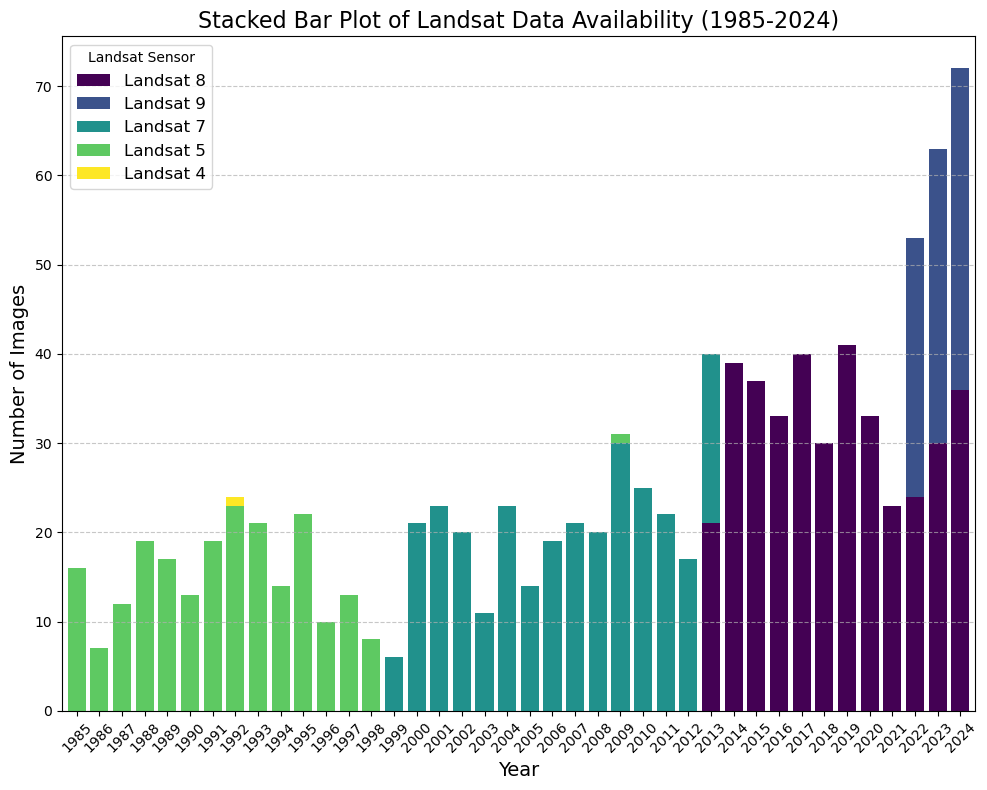

In [6]:
import ee
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import rcParams

# Initialize the Earth Engine API
ee.Initialize()

# Define your geometry as an ee.Geometry object
geometry = ee.Geometry.Point([-50.612, 70.3829])  # Coordinates for West Greenland

# Define a date range
start_date = '1980-01-01'
end_date = '2024-12-01'

# Function to filter image collections for cloud cover
def filter_cloud_cover(collection, geometry, start_date, end_date, max_cloud_cover):
    return collection.filterBounds(geometry)\
                     .filterDate(start_date, end_date)\
                     .filter(ee.Filter.lt('CLOUD_COVER', max_cloud_cover))

# Define the Landsat image collections
landsat_collections = {
    'Landsat 8': ee.ImageCollection('LANDSAT/LC08/C02/T1_L2'),
    'Landsat 9': ee.ImageCollection('LANDSAT/LC09/C02/T1_L2'),
    'Landsat 7': ee.ImageCollection('LANDSAT/LE07/C02/T1_L2'),
    'Landsat 5': ee.ImageCollection('LANDSAT/LT05/C02/T1_L2'),
    'Landsat 4': ee.ImageCollection('LANDSAT/LT04/C02/T1_L2')
}

# Store counts by year and sensor
data = {sensor: [] for sensor in landsat_collections.keys()}

for sensor, collection in landsat_collections.items():
    filtered_collection = filter_cloud_cover(collection, geometry, start_date, end_date, 30)
    dates = filtered_collection.aggregate_array('system:time_start').getInfo()
    dates = pd.to_datetime(dates, unit='ms')
    year_counts = dates.year.value_counts().sort_index()
    data[sensor] = year_counts

# Create a DataFrame and fill missing years
years = range(1985, 2025)
df = pd.DataFrame(data, index=years).fillna(0)

# Set font
rcParams['font.family'] = 'Helvetica'

# Plot: Improved Stacked Bar Plot
plt.figure(figsize=(10, 8))
df.plot(kind='bar', stacked=True, ax=plt.gca(), width=0.8, cmap='viridis')
plt.title('Stacked Bar Plot of Landsat Data Availability (1985-2024)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Images', fontsize=14)
plt.legend(title='Landsat Sensor', loc='upper left', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
